<div style="background:linear-gradient(135deg,#4c1d95 0%,#6d28d9 55%,#a78bfa 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ddd6fe;font-weight:700;text-transform:uppercase">Chapter 197 &middot; Capstone 35 &middot; Reinforcement Learning</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Learning a Pricing Policy</div>
  <div style="font-size:15px;color:#ddd6fe;max-width:820px;line-height:1.6">Twenty weeks of history says that raising prices raises demand. Six weeks of randomization says otherwise. And the reinforcement learning agent, trained on a correct simulator, loses to a grid search over four hundred combinations.</div>
</div>

In [1]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import statsmodels.api as sm
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
VI, DK, LT, MUT, GD, RD = "#6d28d9", "#4c1d95", "#a78bfa", "#94a3b8", "#047857", "#dc2626"

BASE_URL = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-reinforcement-learning-pricing.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE_URL + fn, sheet_name=sheet)
A = load("Log_A"); B = load("Log_B"); P = load("Products"); notes = load("Notes")
MULT = np.array([0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15])
LIST = P.set_index("product_id").list_price.to_dict()
COST = P.set_index("product_id").unit_cost.to_dict()
SESS = B.groupby("product_id").sessions.mean().to_dict()
print(f"Log A {len(A):,} product-days   Log B {len(B):,} product-days   {len(P)} products")

Log A 5,600 product-days   Log B 3,360 product-days   40 products


## Step 1 &middot; The brief

In [2]:
for line in notes.Notes.fillna(""):
    print(line)

CAPSTONE 35 - LEARNING A PRICING POLICY

THE REQUEST. The trading team wants an agent that sets prices day by day instead of
the cost-plus rule the site has used for years. They have twenty weeks of history and
would like to know what the agent would have earned on it.

WHAT IS IN THE FILE
  Log_A  140 days of business as usual. Price was set by a fixed cost-plus markup by
         category, with a sitewide sale every fifth week. No other price variation.
  Log_B   84 days of a randomized price experiment run afterwards on the same products.
         Each WEEK each product was assigned one of seven price multipliers at random
         and held it for seven days, and THE ASSIGNMENT PROBABILITY WAS LOGGED. That
         column is not decoration, and neither is the holding period.

THE THING TO WORK OUT FIRST. Whether the twenty weeks of history can tell you what
happens to demand when you change a price. Fit the obvious regression on Log_A before
reading any further and look at the sign 

## Step 2 &middot; The regression the trading team already ran

Twenty weeks of history, price and units on every product every day. Fit the obvious model.

In [3]:
def demand_fit(L, spec):
    g = L[L.sessions > 0].copy()
    X = pd.DataFrame(index=g.index)
    if "fe" in spec:
        X = pd.get_dummies(g.product_id.astype(str), prefix="p", drop_first=True).astype(float)
    if "level" in spec:
        X["log_price_vs_list"] = np.log(g.price/g.product_id.map(LIST)).values
    if "gap" in spec:
        X["log_price_vs_reference"] = np.log(g.price/g.reference_price).values
    if "raw" in spec:
        X["log_price"] = np.log(g.price).values
    if "wknd" in spec:
        X["weekend"] = (g.day_of_week >= 5).astype(float).values
    X = sm.add_constant(X)
    return sm.GLM(np.c_[g.units, g.sessions - g.units], X, family=sm.families.Binomial()).fit()

r = demand_fit(A, ["raw"])
print("LOG A, conversion against log price, across all products")
print(f"  price coefficient {r.params['log_price']:+.3f}  (standard error {r.bse['log_price']:.3f})")
print("\n  Read literally: raising the price raises the chance somebody buys.")

LOG A, conversion against log price, across all products
  price coefficient +0.766  (standard error 0.005)

  Read literally: raising the price raises the chance somebody buys.


That is not a small effect or a marginal result. It is a firmly estimated, tightly bounded, completely wrong number, and the reason is in the product table: the expensive products are the good ones.

In [4]:
q = P.assign(dear=P.list_price > P.list_price.median())
print(q.groupby("dear")[["list_price","unit_cost","quality_index"]].mean().round(2).to_string())
print(f"\ncorrelation between list price and quality index: "
      f"{np.corrcoef(P.list_price, P.quality_index)[0,1]:.3f}")

       list_price  unit_cost  quality_index
dear                                       
False       14.91       8.65          -0.73
True        77.92      44.98           0.61

correlation between list price and quality index: 0.723


Price is not an experiment that was run on customers. It is a cost-plus markup applied to a catalogue in which better products cost more to make, so the cross-sectional comparison is between different products rather than between different prices for the same product.

The repair looks obvious: compare a product against itself.

In [5]:
for nm, L in [("Log A, the cost-plus history", A), ("Log B, the randomized experiment", B)]:
    f = demand_fit(L, ["fe","level","gap","wknd"])
    ci = f.conf_int()
    print(nm)
    for k, lab in [("log_price_vs_list", "long run, price against list "),
                   ("log_price_vs_reference", "short run, price against reference")]:
        print(f"   {lab} {f.params[k]:+7.3f}   95% CI [{ci.loc[k,0]:+.2f}, {ci.loc[k,1]:+.2f}]")
    print()

Log A, the cost-plus history
   long run, price against list   -4.717   95% CI [-5.13, -4.30]
   short run, price against reference  -2.064   95% CI [-2.52, -1.61]

Log B, the randomized experiment
   long run, price against list   -1.796   95% CI [-2.12, -1.47]
   short run, price against reference  -2.103   95% CI [-2.47, -1.74]



Product fixed effects fix the sign and do not fix the number. Log A puts the long-run elasticity near **-4.7**, which is more than twice what the experiment finds.

The reason is that after the fixed effects there is almost no price variation left in Log A. The only time a product's price moves is the sitewide sale every fifth week, and the sale never arrives on its own: it comes with the email blast and the homepage banner. So the one price change in the dataset is perfectly confounded with a demand shock, and the model attributes the whole of the promotional lift to the price cut.

**A fixed effect can remove a confounder between units. It cannot manufacture variation that was never there.**

## Step 3 &middot; What the experiment bought, and why the holding period mattered

In [6]:
for nm, L in [("Log A", A), ("Log B", L2 := B)]:
    m = (L.price/L.product_id.map(LIST)).round(2)
    print(f"  {nm}: price multipliers ever shown -> {sorted(m.unique())}")
print("\n  Log B assigned each product a multiplier for a WHOLE WEEK at a time.")
print("  Holding it is what lets the reference price drift away from the list price,")
print("  and without that drift the two elasticities cannot be told apart.")
print(f"\n  spread of reference/list in Log A: "
      f"{(A.reference_price/A.product_id.map(LIST)).std():.4f}")
print(f"  spread of reference/list in Log B: "
      f"{(B.reference_price/B.product_id.map(LIST)).std():.4f}")

  Log A: price multipliers ever shown -> [np.float64(0.85), np.float64(1.0)]
  Log B: price multipliers ever shown -> [np.float64(0.85), np.float64(0.9), np.float64(0.95), np.float64(1.0), np.float64(1.05), np.float64(1.1), np.float64(1.15)]

  Log B assigned each product a multiplier for a WHOLE WEEK at a time.
  Holding it is what lets the reference price drift away from the list price,
  and without that drift the two elasticities cannot be told apart.

  spread of reference/list in Log A: 0.0236
  spread of reference/list in Log B: 0.0489


There is a second reason the randomization matters, and it is the one that decides whether any of the rest of this notebook is possible.

**Offline policy evaluation needs every action to have been possible.** To estimate what a new pricing policy would have earned, from data generated by the old one, the standard tool is inverse propensity weighting: reweight each logged outcome by how likely the new policy was to take the action that was actually taken, divided by how likely the old one was. If the old policy could never have chosen an action, that denominator is zero and the estimate does not exist.

Under the cost-plus rule, **five of the seven price points have probability zero**. No amount of statistical machinery recovers what would have happened at a price nobody ever charged.

## Step 4 &middot; Offline evaluation, on the log that supports it

In [7]:
f = demand_fit(B, ["fe","level","gap","wknd"])
LR, SR, WK = (float(f.params["log_price_vs_list"]),
              float(f.params["log_price_vs_reference"]), float(f.params["weekend"]))
BASE = {}
for j in P.product_id:
    c = f"p_{j}"
    BASE[j] = float(f.params["const"]) + (float(f.params[c]) if c in f.params else 0.0)

# a candidate policy: charge 1.10 x list on everything
def candidate(j):  return 1.10
b = B.copy()
b["mult"] = (b.price/b.product_id.map(LIST)).round(2)
b["target"] = b.product_id.map(lambda j: candidate(j))
b["match"] = (np.abs(b.mult - b.target) < 1e-6).astype(float)
b["margin_per_session"] = b.margin/b.sessions
ips = (b.match/b.assignment_prob*b.margin_per_session)
n = len(b)
est, se = ips.mean(), ips.std(ddof=1)/np.sqrt(n)
print("INVERSE PROPENSITY ESTIMATE of margin per session under 'always charge 1.10 x list'")
print(f"  {est:.4f} dollars per session   95% CI [{est-1.96*se:.4f}, {est+1.96*se:.4f}]")
print(f"  logged policy actually earned  {b.margin_per_session.mean():.4f} dollars per session")
print(f"\n  effective sample size {1/((b.match/b.assignment_prob/n)**2).sum():,.0f} of {n:,} rows")
print("  Only the rows where the experiment happened to show 1.10 carry any information.")

INVERSE PROPENSITY ESTIMATE of margin per session under 'always charge 1.10 x list'
  5.0799 dollars per session   95% CI [3.8625, 6.2973]
  logged policy actually earned  5.0460 dollars per session

  effective sample size 465 of 3,360 rows
  Only the rows where the experiment happened to show 1.10 carry any information.


The estimate is unbiased and the interval is wide, and both facts come from the same place: a policy that always charges 1.10 only learns from the tenth of the log where 1.10 was the assigned price. Evaluating a *deterministic* policy offline throws away most of the data by construction, which is the honest cost of not deploying it.

Now build the simulator, which is the alternative and carries its own problems.

## Step 5 &middot; The simulator is the model

In [8]:
def run(policy, days=180, seed=0, lr=None, sr=None):
    rs = np.random.default_rng(seed)
    lr = LR if lr is None else lr
    sr = SR if sr is None else sr
    ref = {j: LIST[j] for j in P.product_id}
    total = 0.0
    for t in range(days):
        dow = t % 7
        for j in P.product_id:
            m = policy(j, t, dow, ref[j]/LIST[j])
            p = LIST[j]*m
            lin = BASE[j] + lr*np.log(m) + sr*np.log(p/ref[j]) + WK*(dow >= 5)
            u = rs.binomial(max(int(rs.poisson(SESS[j])), 0), 1/(1 + np.exp(-lin)))
            total += u*(p - COST[j])
            ref[j] = 0.90*ref[j] + 0.10*p           # tomorrow's expectation
    return total
def avg(policy, n=8, **kw): return float(np.mean([run(policy, seed=s, **kw) for s in range(n)]))

def cost_plus(j, t, dow, rr): return 0.85 if ((t//7) % 5 == 4) else 1.00
v_rule = avg(cost_plus)
print(f"the cost-plus rule, 180 simulated days: ${v_rule:,.0f}")

the cost-plus rule, 180 simulated days: $2,670,341


Every number from here on is produced by that function, which means every number from here on is a statement about the demand model rather than about customers. The agent will exploit anything the model gets wrong, and it will do so enthusiastically. Section 9 measures how much that matters.

## Step 6 &middot; Greedy, and the promotion trap

In [9]:
def greedy(j, t, dow, rr):
    best, bv = 1.0, -1e18
    for m in MULT:
        lin = BASE[j] + LR*np.log(m) + SR*np.log(m/rr) + WK*(dow >= 5)
        v = 1/(1 + np.exp(-lin))*(LIST[j]*m - COST[j])
        if v > bv: bv, best = v, m
    return best

# one fixed multiplier per product, chosen by simulating the whole horizon
FIXED = {}
for j in P.product_id:
    bv, bm = -1e18, 1.0
    for m in MULT:
        ref, tot = LIST[j], 0.0
        for t in range(180):
            p = LIST[j]*m
            lin = BASE[j] + LR*np.log(m) + SR*np.log(p/ref) + WK*((t % 7) >= 5)
            tot += 1/(1 + np.exp(-lin))*(p - COST[j])*SESS[j]
            ref = 0.90*ref + 0.10*p
        if tot > bv: bv, bm = tot, m
    FIXED[j] = bm
def fixed(j, t, dow, rr): return FIXED[j]

v_greedy, v_fixed = avg(greedy), avg(fixed)
print(f"  cost-plus rule                                 ${v_rule:12,.0f}")
print(f"  greedy, best price for today                   ${v_greedy:12,.0f}  {(v_greedy/v_rule-1)*100:+6.1f}%")
print(f"  one fixed price, best over the whole horizon   ${v_fixed:12,.0f}  {(v_fixed/v_rule-1)*100:+6.1f}%")
print()
print(f"  greedy charges on average  {np.mean([greedy(j,0,0,1.0) for j in P.product_id]):.3f} x list")
print(f"  fixed charges on average   {np.mean(list(FIXED.values())):.3f} x list")

  cost-plus rule                                 $   2,670,341
  greedy, best price for today                   $   3,266,629   +22.3%
  one fixed price, best over the whole horizon   $   3,516,368   +31.7%

  greedy charges on average  0.895 x list
  fixed charges on average   1.146 x list


The greedy agent cuts prices by about ten percent. The far-sighted one raises them by about fifteen, and earns **7.6 percent more**.

This is the promotion trap, and the arithmetic behind it is worth stating. Cutting the price today buys the full short-run response, estimated at about **-2.1**, because customers are comparing today's price with what they expected. Hold the cut and the expectation follows it down over a few weeks, and all that is left is the long-run response of about **-1.8** against a permanently lower price. The lift is temporary and the margin loss is not.

**A myopic agent sees only the first number**, which is the larger of the two, so it discounts. The mistake is not in the optimisation, it is in the horizon.

## Step 7 &middot; Reinforcement learning, properly

The fixed-price search cannot vary the price with circumstances. A reinforcement learner can: it observes a state, takes an action, and learns a value for each pair. Here the state that matters is where the reference price sits relative to list, the action is one of seven multipliers, and the reward is the day's margin.

In [10]:
BINS = np.array([0.90, 0.96, 1.02, 1.08])
def sbin(rr): return int(np.digitize(rr, BINS))

def train_q(gamma, episodes=300, steps=60, alpha=0.15, eps=0.20, seed=5):
    Q = {j: np.zeros((len(BINS)+1, len(MULT))) for j in P.product_id}
    rs = np.random.default_rng(seed)
    for _ in range(episodes):
        for j in P.product_id:
            ref = LIST[j]*float(rs.uniform(0.88, 1.12))
            for t in range(steps):
                s = sbin(ref/LIST[j])
                a = int(rs.integers(len(MULT))) if rs.random() < eps else int(Q[j][s].argmax())
                m = MULT[a]; p = LIST[j]*m
                lin = BASE[j] + LR*np.log(m) + SR*np.log(p/ref) + WK*((t % 7) >= 5)
                r = 1/(1 + np.exp(-lin))*(p - COST[j])*SESS[j]
                ref2 = 0.90*ref + 0.10*p
                Q[j][s, a] += alpha*(r + gamma*Q[j][sbin(ref2/LIST[j])].max() - Q[j][s, a])
                ref = ref2
    return Q

print(f"  {'discount':>9s} {'effective horizon':>20s} {'margin':>14s} {'vs the rule':>12s} {'mean multiplier':>17s}")
QS = {}
for gamma, epi, stp in [(0.90, 300, 60), (0.97, 300, 60), (0.995, 300, 120), (0.999, 400, 180)]:
    Q = train_q(gamma, epi, stp); QS[gamma] = Q
    pol = lambda j, t, dow, rr, Q=Q: MULT[int(Q[j][sbin(rr)].argmax())]
    v = avg(pol)
    mm = np.mean([MULT[int(Q[j][s].argmax())] for j in P.product_id for s in range(len(BINS)+1)])
    print(f"  {gamma:9.3f} {1/(1-gamma):17.0f} days ${v:13,.0f} {(v/v_rule-1)*100:+11.1f}% {mm:17.3f}")

   discount    effective horizon         margin  vs the rule   mean multiplier


      0.900                10 days $    3,380,090       +26.6%             0.951


      0.970                33 days $    3,068,521       +14.9%             0.961


      0.995               200 days $    3,045,479       +14.0%             0.962


      0.999              1000 days $    2,960,571       +10.9%             0.917


Every one of them loses to the fixed-price grid search, and a longer horizon makes it worse rather than better. That result is worth taking seriously rather than tuning away, so look at the policy it actually learned.

In [11]:
Q = QS[0.90]
lab = ["below 0.90", "0.90 to 0.96", "0.96 to 1.02", "1.02 to 1.08", "above 1.08"]
print("what the agent charges, by where the reference price sits")
for s in range(len(BINS)+1):
    print(f"  reference / list {lab[s]:14s}  mean multiplier "
          f"{np.mean([MULT[int(Q[j][s].argmax())] for j in P.product_id]):.3f}")

what the agent charges, by where the reference price sits
  reference / list below 0.90      mean multiplier 1.015
  reference / list 0.90 to 0.96    mean multiplier 0.974
  reference / list 0.96 to 1.02    mean multiplier 0.965
  reference / list 1.02 to 1.08    mean multiplier 0.906
  reference / list above 1.08      mean multiplier 0.896


**The agent has learned to chase the reference price.** When customers expect a high price it discounts, and when they expect a low one it raises. Every one of those moves is locally sensible: if the reference is above the list price then a cut is unusually effective today, and the agent has correctly noticed.

The result is a policy that oscillates, and an oscillating price keeps the reference somewhere in the middle instead of walking it upward to a level a constant high price would sustain. Longer horizons make it worse because a five-state discretisation of a slowly-drifting continuous variable propagates its own approximation error every time the value is bootstrapped.

None of that is a bug in the algorithm. The state representation is too coarse for the dynamics, and a grid search over 40 products times 7 prices, four hundred and eighty combinations evaluated by direct simulation, does not have that problem because it does not approximate anything.

> **The useful reading of this section is not that reinforcement learning does not work.** It is that a method with a state space, a discount factor, a learning rate and an exploration schedule has four ways to be wrong that a grid search does not have, and it has to earn its place against the simplest thing that represents the same dynamics.

## Step 8 &middot; What exploration costs

An agent that only ever charges its current best price never learns whether a different one is better. The standard answer is to explore some fraction of the time, and that fraction has a price.

In [12]:
best_pol = lambda j, t, dow, rr: MULT[int(QS[0.90][j][sbin(rr)].argmax())]
def with_exploration(eps, days=180, seed=0):
    rs = np.random.default_rng(1000 + seed)
    ref = {j: LIST[j] for j in P.product_id}; tot = 0.0
    for t in range(days):
        for j in P.product_id:
            rr = ref[j]/LIST[j]
            m = MULT[int(rs.integers(len(MULT)))] if rs.random() < eps else best_pol(j, t, t % 7, rr)
            p = LIST[j]*m
            lin = BASE[j] + LR*np.log(m) + SR*np.log(p/ref[j]) + WK*((t % 7) >= 5)
            tot += rs.binomial(max(int(rs.poisson(SESS[j])), 0), 1/(1 + np.exp(-lin)))*(p - COST[j])
            ref[j] = 0.90*ref[j] + 0.10*p
    return tot

v_none = np.mean([with_exploration(0.0, seed=s) for s in range(6)])
for eps in [0.0, 0.05, 0.10, 0.20]:
    v = np.mean([with_exploration(eps, seed=s) for s in range(6)])
    print(f"  exploring {eps:4.0%} of the time   ${v:12,.0f}   {(v/v_none-1)*100:+5.1f}%")

  exploring   0% of the time   $   3,390,623    +0.0%
  exploring   5% of the time   $   3,362,474    -0.8%


  exploring  10% of the time   $   3,309,230    -2.4%
  exploring  20% of the time   $   3,250,799    -4.1%


Exploring one day in five costs about **four percent** of margin over six months, and the cost is close to linear: roughly a fifth of a percent for each percentage point of exploration.

That number is a property of the action set rather than of the algorithm. The cost of exploring is the gap between the best action and the average random one, and here the actions run only from 0.85 to 1.15 times list, so the worst thing exploration can do is charge fifteen percent too little for a day. **Widen the action set and the calculation changes completely.** An agent allowed to try half price would pay a great deal more for the same information, which is an argument for constraining the action set rather than for exploring freely, and it is the lever to reach for first when exploration looks too expensive to justify.

## Step 9 &middot; How much does getting the simulator wrong cost?

The agent was trained inside a demand model estimated from six weeks of data. Retrain it on deliberately wrong versions of that model and evaluate every resulting policy in the same, fixed, correct simulator.

In [13]:
def fixed_policy_from(lr_, sr_):
    out = {}
    for j in P.product_id:
        bv, bm = -1e18, 1.0
        for m in MULT:
            ref, tot = LIST[j], 0.0
            for t in range(180):
                p = LIST[j]*m
                lin = BASE[j] + lr_*np.log(m) + sr_*np.log(p/ref) + WK*((t % 7) >= 5)
                tot += 1/(1 + np.exp(-lin))*(p - COST[j])*SESS[j]
                ref = 0.90*ref + 0.10*p
            if tot > bv: bv, bm = tot, m
        out[j] = bm
    return out

print(f"  {'the simulator it was trained on':34s} {'earns':>14s} {'vs the honest one':>19s} {'charges':>9s}")
rows = [("the fitted demand model",        LR,       SR),
        ("elasticities 30 percent smaller", LR*0.7,  SR*0.7),
        ("elasticities 30 percent larger",  LR*1.3,  SR*1.3),
        ("the reference effect ignored",    LR + SR, 0.0)]
ref_v = None
for nm, lr_, sr_ in rows:
    pol = fixed_policy_from(lr_, sr_)
    v = avg(lambda j, t, dow, rr, pol=pol: pol[j])
    if ref_v is None: ref_v = v
    print(f"  {nm:34s} ${v:13,.0f} {(v/ref_v-1)*100:18.1f}% "
          f"{np.mean(list(pol.values())):9.3f}")

  the simulator it was trained on             earns   vs the honest one   charges


  the fitted demand model            $    3,516,368                0.0%     1.146
  elasticities 30 percent smaller    $    3,516,377                0.0%     1.150


  elasticities 30 percent larger     $    3,494,613               -0.6%     1.040


  the reference effect ignored       $    3,291,650               -6.4%     0.897


The pattern is the interesting part. **Getting the size of the elasticities wrong by thirty percent in either direction costs almost nothing.** The policy shifts by one price point at most, and the margin surface is flat enough near its optimum that it barely registers.

**Getting the structure wrong costs six percent.** The last row folds the short-run and long-run responses into a single number, which is exactly what an analyst does by default if nobody tells them customers anchor on recent prices. That policy discounts, because it believes the whole of the promotional lift is permanent.

That is a general lesson about simulators and it is not specific to pricing. The parameter values can be some way off and the policy survives. If the state variable is missing, the policy is optimising the wrong problem, and no amount of data on the parameters will find that out.

## Step 10 &middot; The answer key

In [14]:
T = load("Truth")
print("ELASTICITIES: what we estimated against what generated the data")
print(f"  long run   estimated {LR:+.3f}   truth {T.true_long_run_elasticity.mean():+.3f}")
print(f"  short run  estimated {SR:+.3f}   truth {T.true_short_run_elasticity.mean():+.3f}")
print("\n  Both are mildly attenuated. The logs aggregate sessions to product-days, so the")
print("  traffic-source variation inside a day is averaged away, and averaging inside a")
print("  logit shrinks a coefficient toward zero. The ordering and the ratio survive it,")
print("  and the ordering is what the policy depends on.")

ELASTICITIES: what we estimated against what generated the data
  long run   estimated -1.796   truth -1.605
  short run  estimated -2.103   truth -2.462

  Both are mildly attenuated. The logs aggregate sessions to product-days, so the
  traffic-source variation inside a day is averaged away, and averaging inside a
  logit shrinks a coefficient toward zero. The ordering and the ratio survive it,
  and the ordering is what the policy depends on.


## Step 11 &middot; The pictures

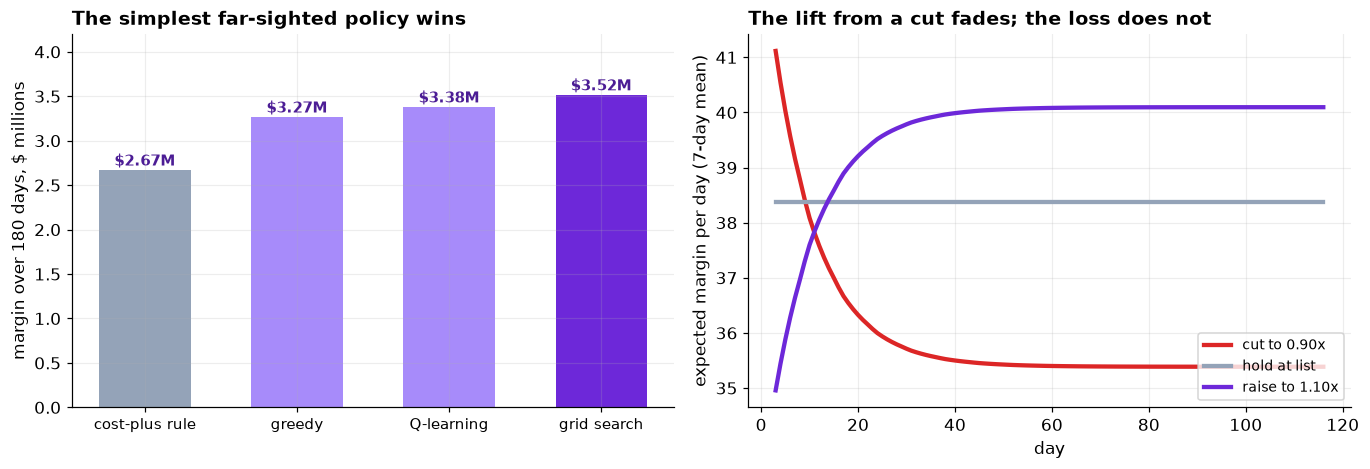

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
labs = ["cost-plus rule", "greedy", "Q-learning", "grid search"]
vals = [v_rule, v_greedy, avg(best_pol), v_fixed]
ax.bar(np.arange(4), np.array(vals)/1e6, color=[MUT, LT, LT, VI], width=0.6)
for x, v in zip(np.arange(4), vals):
    ax.text(x, v/1e6 + 0.05, f"${v/1e6:.2f}M", ha="center", fontsize=10, fontweight="bold", color=DK)
ax.set_xticks(np.arange(4)); ax.set_xticklabels(labs, fontsize=9.5)
ax.set_ylabel("margin over 180 days, $ millions"); ax.set_ylim(0, 4.2)
ax.set_title("The simplest far-sighted policy wins")

ax = axes[1]
j = int(P.product_id.iloc[0])
for m, col, lab in [(0.90, RD, "cut to 0.90x"), (1.00, MUT, "hold at list"), (1.10, VI, "raise to 1.10x")]:
    ref, series = LIST[j], []
    for t_ in range(120):
        p_ = LIST[j]*m
        lin = BASE[j] + LR*np.log(m) + SR*np.log(p_/ref) + WK*((t_ % 7) >= 5)
        series.append(1/(1+np.exp(-lin))*(p_ - COST[j])*SESS[j])
        ref = 0.90*ref + 0.10*p_
    sm = pd.Series(series).rolling(7, center=True).mean()
    ax.plot(range(120), sm, color=col, lw=2.8, label=lab)
ax.set_xlabel("day"); ax.set_ylabel("expected margin per day (7-day mean)")
ax.set_title("The lift from a cut fades; the loss does not")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

**Left:** the four policies over the same simulated six months. **Right:** why the greedy agent is wrong. A ten percent cut is ahead of holding list price for about twelve days, and behind it for the remaining hundred and eight.

## Step 12 &middot; What none of this settles

**The simulator has no competitors in it.** Raise prices fifteen percent across a catalogue and somebody else does not. Every number in sections 6 to 9 assumes the rest of the market holds still, which is the assumption most likely to be false and the one this data cannot test.

**Six weeks of randomization estimated two parameters.** It did not measure whether the reference-price mechanism is the right model of customer memory, only what the coefficients are if it is. A different anchoring model, say one where customers remember the lowest price they have seen rather than an average, would give a different optimal policy from the same data.

**Charging different customers different prices is not the same problem as charging different prices over time.** Everything here sets one price per product per day for everybody. Personalised pricing raises questions about fairness and about disclosure that are not statistical and are not answered by a higher expected margin.

**And the whole exercise reprices a catalogue that was priced by a rule for years.** A fifteen percent increase across forty products is a business decision with consequences for customer trust that a 180-day margin simulation is not equipped to see. The right output of this project is a proposed experiment, not a deployed agent.

---

### What to take away

1. **Twenty weeks of business-as-usual data said that raising prices raises demand.** Price was a cost-plus markup on a catalogue where better products cost more, so the comparison was between products, not between prices.
2. **Product fixed effects fixed the sign and not the number**, because the only price movement left was the sale weeks, and those came with a marketing push.
3. **Offline policy evaluation needs every action to have been possible.** Five of the seven price points had probability zero under the old rule, and no method recovers a price nobody charged.
4. **The experiment had to hold each price for a week.** Daily randomization identifies the total price response but cannot separate the short-run from the long-run effect, because the reference price never moves.
5. **A myopic agent discounts.** It sees the short-run response of -2.1 and not the long-run -1.8 that is left once expectations catch up, and it earns 7.6 percent less than a far-sighted one.
6. **The Q-learner lost to a grid search over 480 combinations**, and the policy it learned explains why: it chases the reference price, which is locally right everywhere and globally a loss.
7. **Exploring one day in five cost four percent**, and roughly a fifth of a percent per point of exploration. That price is set by how wide the action set is, not by the algorithm.
8. **Thirty percent errors in the elasticities cost under one percent; omitting the reference effect cost six.** Simulators tolerate wrong parameters and not missing state.